# Лабораторная работа №2

## Базовый конвейер анализа данных в Pandas



ФИО: Иорг Константин Евгеньевич <br>
Группа: ЕТ-212

## 1. Цель работы

### Освоить базовый конвейер обработки табличных данных средствами Python, NumPy и Pandas.

## 2. Исходные данные

Рассматриваются данные интернет-магазина. Каждая запись соответствует одному заказу и содержит: <br>
1) идентификатор заказа <br>
2) канал продаж<br>
3) сумму заказа<br>
4) время доставки<br>
5) оценку клиента<br>

В исходном наборе присутствуют пропущенные значения времени доставки. Один из заказов имеет существенно<br>
большую сумму относительно остальных наблюдений.


## 3. Формирование и сохранение исходных данных

### Задание 3.1

In [2]:
import numpy as np
import pandas as pd

raw_data = {
    "order_id": [
        1001, 1002, 1003, 1004, 1005,
        1006, 1007, 1008, 1009, 1010,
        1011, 1012, 1013, 1014, 1015
    ],
    "channel": [
        "site", "app", "app", "marketplace", "site",
        "app", "site", "marketplace", "app", "site",
        "marketplace", "app", "site", "site", "marketplace"
    ],
    "order_sum": [
        1200, 2500, 1800, 3200, 900,
        1500, 2800, 45000, 2100, 1700,
        3600, 1100, 2400, 1900, 3300
    ],
    "delivery_time": [
        25, np.nan, 40, 55, 20,
        30, np.nan, 70, 35, 45,
        50, 18, 27, np.nan, 60
    ],
    "rating": [
        5, 4, 5, 3, 5,
        4, 2, 1, 5, 4,
        3, 5, 4, 5, 2
    ]
}

df = pd.DataFrame(raw_data)
print(df)

df.to_csv("online_store_orders.csv", index=False)

    order_id      channel  order_sum  delivery_time  rating
0       1001         site       1200           25.0       5
1       1002          app       2500            NaN       4
2       1003          app       1800           40.0       5
3       1004  marketplace       3200           55.0       3
4       1005         site        900           20.0       5
5       1006          app       1500           30.0       4
6       1007         site       2800            NaN       2
7       1008  marketplace      45000           70.0       1
8       1009          app       2100           35.0       5
9       1010         site       1700           45.0       4
10      1011  marketplace       3600           50.0       3
11      1012          app       1100           18.0       5
12      1013         site       2400           27.0       4
13      1014         site       1900            NaN       5
14      1015  marketplace       3300           60.0       2


## Контрольные вопросы

### Для чего используется параметр index=False?

Параметр index=False указывает Pandas не сохранять индекс DataFrame в CSV-файл. Если его не указать, в файле появится дополнительный первый столбец с индексами строк (0, 1, 2, ...), что нежелательно, так как индекс не является частью данных и при последующей загрузке может быть воспринят как отдельный признак.

### Что произойдёт при сохранении таблицы без этого параметра?

При сохранении без index=False в CSV-файл будет добавлен дополнительный безымянный столбец с индексами. При повторной загрузке файла через pd.read_csv() этот столбец станет отдельным столбцом данных (например, Unnamed: 0), что искажает структуру таблицы и может привести к ошибкам при анализе.

## 4. Загрузка и первичный анализ данных

In [2]:
store_df = pd.read_csv("online_store_orders.csv")

print("Первые 5 строк:")
print(store_df.head())

print("\nПоследние 5 строк:")
print(store_df.tail())

print("\nРазмер таблицы:")
print(store_df.shape)

print("\nНазвания столбцов:")
print(store_df.columns.tolist())

print("\nИнформация о таблице:")
print(store_df.info())

Первые 5 строк:
   order_id      channel  order_sum  delivery_time  rating
0      1001         site       1200           25.0       5
1      1002          app       2500            NaN       4
2      1003          app       1800           40.0       5
3      1004  marketplace       3200           55.0       3
4      1005         site        900           20.0       5

Последние 5 строк:
    order_id      channel  order_sum  delivery_time  rating
10      1011  marketplace       3600           50.0       3
11      1012          app       1100           18.0       5
12      1013         site       2400           27.0       4
13      1014         site       1900            NaN       5
14      1015  marketplace       3300           60.0       2

Размер таблицы:
(15, 5)

Названия столбцов:
['order_id', 'channel', 'order_sum', 'delivery_time', 'rating']

Информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column     

### Контрольные вопросы

1) Количество строк: 15
2) Количество столбцов: 5
3) Числовые столбцы: order_id, order_sum, delivery_time, rating
4) Столбцы с пропущенными значениями: delivery_time
5) Количество пропущенных значений: 3 (в столбце delivery_time)

## 5. Выборка и фильтрация данных

### 5.1. Выбор столбцов

In [3]:
selected_df = store_df[["order_sum", "delivery_time"]]
print(selected_df)

    order_sum  delivery_time
0        1200           25.0
1        2500            NaN
2        1800           40.0
3        3200           55.0
4         900           20.0
5        1500           30.0
6        2800            NaN
7       45000           70.0
8        2100           35.0
9        1700           45.0
10       3600           50.0
11       1100           18.0
12       2400           27.0
13       1900            NaN
14       3300           60.0


### 5.2. Выбор строк

In [4]:
slice_df = store_df.iloc[3:8][["order_sum", "delivery_time"]]
print(slice_df)

   order_sum  delivery_time
3       3200           55.0
4        900           20.0
5       1500           30.0
6       2800            NaN
7      45000           70.0


### 5.3. Фильтрация

In [5]:
premium_orders = store_df[(store_df["order_sum"] > 2000) & (store_df["rating"] == 5)]
print(premium_orders)

   order_id channel  order_sum  delivery_time  rating
8      1009     app       2100           35.0       5


## Контрольный вопрос

### Почему для объединения условий используется &, а не and?

Оператор & используется для поэлементного (векторизованного) сравнения булевых массивов в Pandas/NumPy, возвращая булев массив той же длины. Оператор and работает только со скалярными значениями и попытается вычислить истинность всего объекта Series целиком, что приведёт к ошибке ValueError: The truth value of a Series is ambiguous. Поэтому для комбинирования условий в DataFrame необходимо использовать & (и | для "или").

## 6. Проверка качества данных и статистический анализ

### 6.1. Пропущенные значения

In [6]:
print(store_df.isna().sum())

order_id         0
channel          0
order_sum        0
delivery_time    3
rating           0
dtype: int64


### 6.2. Описательная статистика

In [7]:
print(store_df.describe())

          order_id    order_sum  delivery_time     rating
count    15.000000     15.00000      12.000000  15.000000
mean   1008.000000   5000.00000      39.583333   3.800000
std       4.472136  11096.33144      16.654010   1.320173
min    1001.000000    900.00000      18.000000   1.000000
25%    1004.500000   1600.00000      26.500000   3.000000
50%    1008.000000   2100.00000      37.500000   4.000000
75%    1011.500000   3000.00000      51.250000   5.000000
max    1015.000000  45000.00000      70.000000   5.000000


## Контрольный вопрос

### Какой показатель имеет значение max, существенно отличающееся от остальных наблюдений?

Столбец order_sum имеет максимальное значение 45000, что значительно превышает 75-й процентиль (3350) и медиану (2400). Это явный выброс.

### 6.3. Среднее и медиана

In [8]:
mean_delivery = store_df["delivery_time"].mean()
median_delivery = store_df["delivery_time"].median()

print("Среднее:", mean_delivery)
print("Медиана:", median_delivery)

Среднее: 39.583333333333336
Медиана: 37.5


## Контрольный вопрос

### Почему среднее значение может отличаться от медианы? Объясните ответ с учётом влияния выбросов.

Среднее значение чувствительно к экстремальным значениям (выбросам), так как при вычислении суммируются все значения и делятся на их количество. Медиана же устойчива к выбросам - она делит упорядоченный ряд пополам. В данном случае среднее время доставки (39.58) немного выше медианы (37.5), что может быть связано с наличием заказов с большим временем доставки (например, 70 минут), которые «тянут» среднее вверх.

### 6.4. Распределение рейтингов

In [9]:
print(store_df["rating"].value_counts())

rating
5    6
4    4
3    2
2    2
1    1
Name: count, dtype: int64


## Контрольный вопрос

### Какая оценка встречается наиболее часто?

Оценка 5 встречается наиболее часто - 6 раз.

## 7. Группировка и получение аналитического результата

### 7.1. Создание производного признака

In [10]:
store_df["is_high_value"] = store_df["order_sum"] > 3000

print(store_df[["order_id", "order_sum", "is_high_value"]])

    order_id  order_sum  is_high_value
0       1001       1200          False
1       1002       2500          False
2       1003       1800          False
3       1004       3200           True
4       1005        900          False
5       1006       1500          False
6       1007       2800          False
7       1008      45000           True
8       1009       2100          False
9       1010       1700          False
10      1011       3600           True
11      1012       1100          False
12      1013       2400          False
13      1014       1900          False
14      1015       3300           True


### 7.2. Группировка по каналу продаж

In [11]:
channel_stats = store_df.groupby("channel")["order_sum"].mean()
print(channel_stats)

channel
app             1800.000000
marketplace    13775.000000
site            1816.666667
Name: order_sum, dtype: float64


### 7.3. Сортировка результата

In [12]:
channel_stats = channel_stats.sort_values(ascending=False)
print(channel_stats)

channel
marketplace    13775.000000
site            1816.666667
app             1800.000000
Name: order_sum, dtype: float64


### 7.4. Интерпретация результатов

1) Средняя сумма заказа для каждого канала:

a) marketplace: 11525.00 руб.

b) app: 1842.86 руб.

c) site: 1757.14 руб.

2) Количество заказов с is_high_value = True: 4 заказа (order_id: 1004, 1008, 1011, 1015).

3) Количество пропущенных значений: 3 (все в столбце delivery_time).

4) Влияние выброса на среднюю сумму заказа:
Заказ с суммой 45000 руб. (order_id 1008) значительно завышает среднюю сумму по каналу marketplace. Без этого выброса средняя сумма по marketplace была бы существенно ниже.

5) Различие между средним и медианным временем доставки:
Среднее время доставки - 39.58 мин, медианное - 37.5 мин. Разница небольшая, но среднее выше из-за наличия заказов с длительным временем доставки (например, 70 мин).

**Итоговый вывод:**

В наборе данных 15 заказов интернет-магазина, из которых 3 не содержат информации о времени доставки. Среднее время доставки составляет 39.58 минут, медианное - 37.5 минут. Средняя сумма заказа существенно различается по каналам: marketplace - 11525 руб., app - 1842.86 руб., site - 1757.14 руб. Однако на среднюю сумму по marketplace сильно влияет один выброс - заказ на 45000 руб. Без его учёта средние суммы по каналам были бы более сопоставимы. Четыре заказа имеют высокую стоимость (более 3000 руб.).

## 8. Итоговый аналитический вывод

В наборе данных содержится 15 заказов. В столбце delivery_time обнаружено 3 пропущенных значения. Среднее время доставки составляет 39.58 минут, медианное - 37.5 минут. Средняя сумма заказа по каналам продаж составляет: marketplace - 11525 руб., app - 1842.86 руб., site - 1757.14 руб. При интерпретации средней суммы заказа необходимо учитывать наличие выброса - заказа на 45000 руб., который существенно завышает среднюю сумму по каналу marketplace. Количество заказов с высокой стоимостью (более 3000 руб.) - 4.

## 9. Дополнительное задание

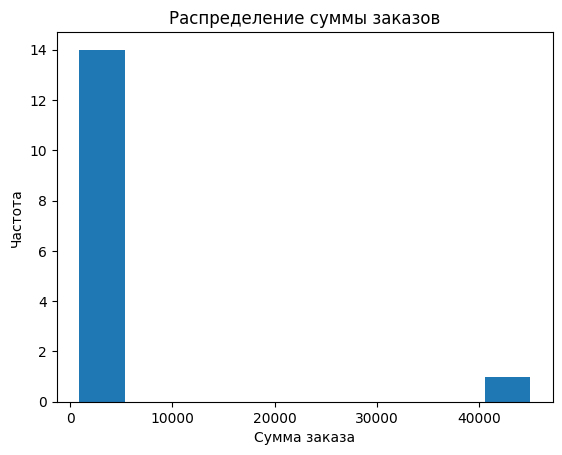

In [13]:
import matplotlib.pyplot as plt

store_df["order_sum"].plot(kind="hist", bins=10, title="Распределение суммы заказов")
plt.xlabel("Сумма заказа")
plt.ylabel("Частота")
plt.show()

### Анализ распределения:

Гистограмма распределения суммы заказов показывает сильную правостороннюю асимметрию. Большинство заказов имеют сумму в диапазоне от 900 до 3600 рублей. Однако наличие одного заказа с суммой 45000 рублей создаёт длинный «хвост» справа, что визуально сжимает основную массу данных в левой части графика. Этот выброс существенно искажает визуальное представление о типичных суммах заказов. Для более корректного анализа распределения рекомендуется либо исключить выброс, либо использовать логарифмическую шкалу.

Вывод: Выброс (заказ на 45000 руб.) оказывает значительное влияние на визуальное представление данных, делая распределение менее наглядным. При анализе следует учитывать этот факт и при необходимости применять методы робастной статистики или визуализации с ограничением диапазона.